In [2]:
import pandas as pd

df=pd.read_csv('DSGP1.csv')
df.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2
0,1,-1.277358,-1.383790,1.135865,0.542106,1.140896,1.002092
1,1,-1.791943,-0.901592,0.611183,0.924377,0.653613,0.592133
2,1,-1.841817,0.084884,0.079508,0.197685,0.372667,-0.102832
3,1,-1.235617,0.442259,-0.242087,-0.271637,-0.556082,1.062007
4,0,-0.268737,-0.034063,-0.120322,-0.540362,-0.830400,0.822788


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(["Cluster_Label"], axis=1)
Y = df["Cluster_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)


param_grid = {
    'n_estimators': [200,250,300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [10,15,20],
    'min_samples_leaf': [5,10,15],
    'max_features': ['sqrt','log2'],
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')


grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report,accuracy_score
print(classification_report(y_test,y_pred))

y_train_pred=best_model.predict(X_train)
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")

test_accuracy=accuracy_score(y_test,y_pred)
print(f"Training Accuracy: {test_accuracy * 100:.2f}%")



Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       133
           1       0.98      0.94      0.96       105

    accuracy                           0.97       238
   macro avg       0.97      0.96      0.97       238
weighted avg       0.97      0.97      0.97       238

Training Accuracy: 98.42%
Training Accuracy: 96.64%


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input
from sklearn.model_selection import train_test_split

model = Sequential([
    Input(shape=(6,)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5988 - loss: 0.7061 - val_accuracy: 0.8445 - val_loss: 0.5745
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7401 - loss: 0.5846 - val_accuracy: 0.9496 - val_loss: 0.4745
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8105 - loss: 0.5094 - val_accuracy: 0.9538 - val_loss: 0.3844
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8694 - loss: 0.4084 - val_accuracy: 0.9622 - val_loss: 0.3023
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8953 - loss: 0.3570 - val_accuracy: 0.9622 - val_loss: 0.2376
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9035 - loss: 0.3150 - val_accuracy: 0.9622 - val_loss: 0.1888
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9290 - loss: 0.2416 - val_accuracy: 0.9622 - val_loss: 0.1544
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9416 - loss: 0.2281 - val_accuracy: 0.9580 - val_lo

In [28]:
from sklearn.metrics import classification_report
import numpy as np

y_pred=model.predict(X_test)



y_pred = model.predict(X_test)  
y_pred_labels = (y_pred > 0.5).astype(int)  
print(classification_report(y_test, y_pred_labels))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       133
           1       0.97      0.94      0.96       105

    accuracy                           0.96       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238



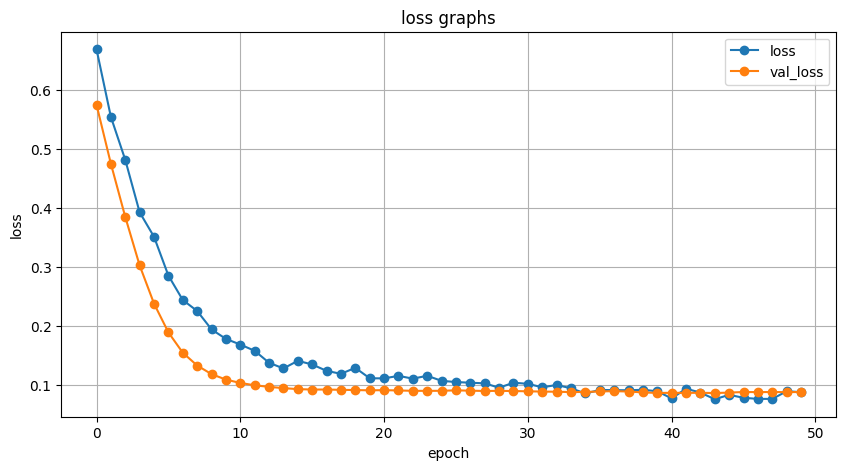

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss',marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("loss graphs")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
from joblib import dump

# Save the model to a file
dump(model, 'neuralNetwork.joblib')


['neuralNetwork.joblib']

In [32]:
dump(best_model,'randomForeset.joblib')

['randomForeset.joblib']